# SARF | EDA and Data Audit

This notebook is our first step before training any model. We use it to understand the approved ArBanking77 splits and check that there are no obvious data issues.

### What we check
- Number of examples and intents in each split.
- Whether the 77 intent labels match across splits.
- Whether the MSA training set is balanced across intents.
- Text-length patterns.
- Missing texts and duplicate texts.

### Important note
This notebook is for **data exploration and quality checks only**. It does not train a model and does not report model performance.


## 1. Setup

We first connect Google Drive, import the libraries, and define the project folders. The data files are read only; this notebook does not edit any original split.


In [11]:
# Connect Google Drive.
from google.colab import drive
drive.mount('/content/drive')

# Libraries used in this notebook.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')

# Main project folders.
PROJECT_ROOT = Path('/content/drive/MyDrive/SARF_BANKING_NLP_PROJECT')
DATA_DIR = PROJECT_ROOT / '02_processed_data'
EDA_TABLE_DIR = PROJECT_ROOT / '04_audits' / 'eda'
EDA_FIGURE_DIR = PROJECT_ROOT / '08_figures' / 'eda'

# Stop early if the project folder or processed data folder is missing.
if not PROJECT_ROOT.exists():
    raise FileNotFoundError('Project folder was not found. Check the folder name.')

if not DATA_DIR.exists():
    raise FileNotFoundError('Processed data folder was not found.')

# Create folders for EDA outputs if they do not exist yet.
EDA_TABLE_DIR.mkdir(parents=True, exist_ok=True)
EDA_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('Using project folder:', PROJECT_ROOT)
print('Data folder:', DATA_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using project folder: /content/drive/MyDrive/SARF_BANKING_NLP_PROJECT
Data folder: /content/drive/MyDrive/SARF_BANKING_NLP_PROJECT/02_processed_data


## 2. Load the data

We load the four CSV files once. Every file should have the same two main columns: `text` and `label`.


In [12]:
# Names and locations of the approved processed data files.
files = {
    'msa_train': DATA_DIR / 'msa_train_v1.csv',
    'msa_val': DATA_DIR / 'msa_val_v1.csv',
    'msa_test': DATA_DIR / 'msa_test_v1.csv',
    'saudi_test': DATA_DIR / 'saudi_test_frozen_v1.csv',
}

# Load the approved data files and check that they have text and label columns.
splits = {}

for split_name, path in files.items():
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path.name}')

    df = pd.read_csv(path)

    if not {'text', 'label'}.issubset(df.columns):
        raise ValueError(f'{path.name} must contain text and label columns.')

    splits[split_name] = df
    print(f'{split_name}: {len(df):,} rows | columns: {list(df.columns)}')


msa_train: 10,732 rows | columns: ['label', 'text']
msa_val: 1,229 rows | columns: ['label', 'text']
msa_test: 3,574 rows | columns: ['label', 'text']
saudi_test: 3,580 rows | columns: ['label', 'text']


## 3. Basic data quality check

Here we check the number of rows, labels, missing values, and duplicate texts in each split.

For the Saudi test split, we only document any duplicates we find. We do not remove or edit anything because it is our frozen evaluation split.


In [13]:
# Check row counts, missing values, duplicates, and label consistency.
def get_duplicate_stats(series):
    text = series.fillna('').astype(str).str.strip()
    counts = text.value_counts()
    repeated_texts = counts[counts > 1]

    return {
        'empty_texts': int((text == '').sum()),
        'duplicate_rows_after_first': int(text.duplicated().sum()),
        'different_texts_that_repeat': int(len(repeated_texts)),
    }

# MSA train is the reference because it is the supervised training split.
train_labels = set(splits['msa_train']['label'].dropna().astype(str))

audit_rows = []
for split_name, df in splits.items():
    current_labels = set(df['label'].dropna().astype(str))

    audit_rows.append({
        'split': split_name,
        'rows': len(df),
        'unique_labels': df['label'].nunique(),
        'missing_labels': int(df['label'].isna().sum()),
        'same_labels_as_msa_train': current_labels == train_labels,
        'missing_intents_vs_msa_train': len(train_labels - current_labels),
        'extra_intents_vs_msa_train': len(current_labels - train_labels),
        **get_duplicate_stats(df['text']),
    })

audit_summary = pd.DataFrame(audit_rows)
display(audit_summary)

audit_summary.to_csv(
    EDA_TABLE_DIR / 'eda_basic_data_quality_summary.csv',
    index=False,
    encoding='utf-8-sig',
)

print('Saved: eda_basic_data_quality_summary.csv')


,split,rows,unique_labels,missing_labels,same_labels_as_msa_train,missing_intents_vs_msa_train,extra_intents_vs_msa_train,empty_texts,duplicate_rows_after_first,different_texts_that_repeat
0,msa_train,10732,77,0,True,0,0,0,0,0
1,msa_val,1229,77,0,True,0,0,0,0,0
2,msa_test,3574,77,0,True,0,0,0,0,0
3,saudi_test,3580,77,0,True,0,0,0,38,37


Saved: eda_basic_data_quality_summary.csv


### Observation

All four splits contain the same 77 intent labels, with no missing labels or empty texts. No duplicate text rows were found in the MSA train, validation, or test splits. The frozen Saudi test split contains 38 duplicate rows representing 37 different repeated text values, and it is kept unchanged for the planned evaluation.


## 4. Intent distribution in MSA training data

This section answers a simple EDA question: does every intent have a similar number of training examples, or are some intents much smaller than others?

We focus on MSA train because it is the split used for supervised training. This also explains why we will use **Macro-F1** as the main metric: it gives every intent equal importance, not only the biggest ones.


,number_of_intents,smallest_intent_size,largest_intent_size,median_intent_size,largest_to_smallest_ratio
0,77,31,291,134.0,9.39


Ten largest intents:


,label,number_of_training_examples
0,لم يستلم المستلم التحويل,291
1,تلقي مبلغ خاطئ من النقد,249
2,تم التحصيل مرتين,248
3,في انتظار التعبئة,220
4,سعر الصرف الخاطئ للدفع بالبطاقة,217
5,إرجاع الدفع بالبطاقة؟,215
6,لم يتم تحديث الرصيد بعد التحويل المصرفي,213
7,تحصيل رسوم التحويل,207
8,تم تحصيل رسوم الدفع بالبطاقة,198
9,وصول البطاقة,197


Ten smallest intents:


,label,number_of_training_examples
76,عدم التلامس لا يعمل,31
75,البطاقة الافتراضية لا تعمل,37
74,قبول البطاقة,55
73,ابتلاع البطاقة,71
72,البطاقة المفقودة أو المسروقة,73
71,دعم أجهزة الصراف الآلي,78
70,تلقي الأموال,88
69,الحصول على بطاقة افتراضية,89
68,الحصول على بطاقة افتراضية يمكن التخلص منها,90
67,غير قادر على التحقق من الهوية,92


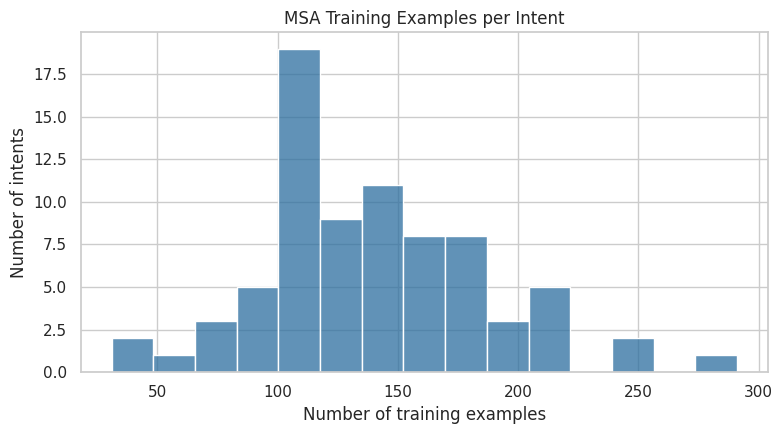

Saved: eda_msa_train_intent_counts.csv and eda_intent_distribution.png


In [14]:
# Count the number of MSA training examples for every intent.
intent_counts = (
    splits['msa_train']['label']
    .value_counts()
    .rename_axis('label')
    .reset_index(name='number_of_training_examples')
)

# Show the basic range first.
summary = pd.DataFrame([{
    'number_of_intents': len(intent_counts),
    'smallest_intent_size': intent_counts['number_of_training_examples'].min(),
    'largest_intent_size': intent_counts['number_of_training_examples'].max(),
    'median_intent_size': intent_counts['number_of_training_examples'].median(),
    'largest_to_smallest_ratio': round(
        intent_counts['number_of_training_examples'].max() /
        intent_counts['number_of_training_examples'].min(), 2
    ),
}])

display(summary)

print('Ten largest intents:')
display(intent_counts.nlargest(10, 'number_of_training_examples'))

print('Ten smallest intents:')
display(intent_counts.nsmallest(10, 'number_of_training_examples'))

intent_counts.to_csv(
    EDA_TABLE_DIR / 'eda_msa_train_intent_counts.csv',
    index=False,
    encoding='utf-8-sig',
)

# A histogram is easier to read than a 77-label bar chart in a small proposal/report.
plt.figure(figsize=(8, 4.5))
sns.histplot(intent_counts['number_of_training_examples'], bins=15, color='#2c6e9f')
plt.title('MSA Training Examples per Intent')
plt.xlabel('Number of training examples')
plt.ylabel('Number of intents')
plt.tight_layout()
plt.savefig(EDA_FIGURE_DIR / 'eda_intent_distribution.png', dpi=200)
plt.show()

print('Saved: eda_msa_train_intent_counts.csv and eda_intent_distribution.png')


### Observation

The MSA training set contains 77 intents. The number of examples per intent ranges from 31 to 291, with a median of 134 examples. The largest intent is about 9.39 times larger than the smallest intent. Most intents have roughly 100–200 training examples, but a small number of intents have much lower support.

This means that the training data are not perfectly balanced across intents. Therefore, Macro-F1 will be used as the primary evaluation metric because it gives equal importance to both high-support and low-support intents.


## 5. Text-length analysis

Banking queries are usually short, but it is still useful to check their length. Here we compare character length and word-count length across the four splits.

This is descriptive only. We use it later to support a reasonable token-length choice, not to make a model decision from the Saudi test.


,split,mean_words,median_words,95th_percentile_words,maximum_words,mean_characters
0,msa_train,9.97,8.0,25.0,68,52.51
1,msa_val,10.27,8.0,25.0,61,54.01
2,msa_test,9.35,8.0,21.0,58,49.42
3,saudi_test,7.83,7.0,17.0,45,41.12


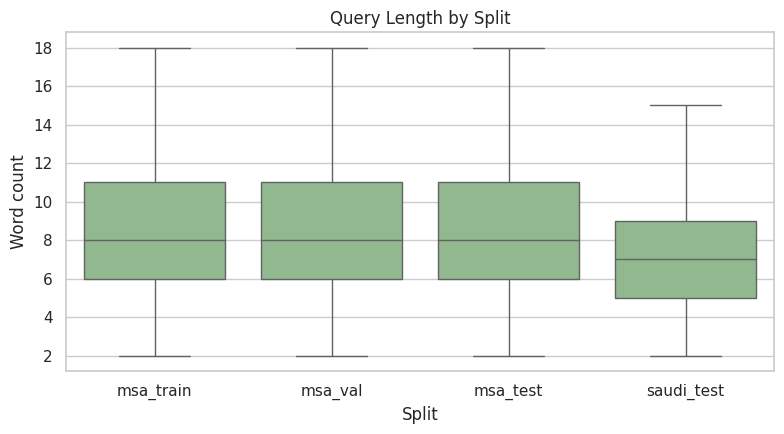

Saved: eda_text_length_summary.csv and eda_text_length_by_split.png


In [15]:
# Calculate simple text-length features for each split.
length_rows = []
plot_data = []

for split_name, df in splits.items():
    clean_text = df['text'].fillna('').astype(str).str.strip()
    word_length = clean_text.str.split().str.len()
    char_length = clean_text.str.len()

    length_rows.append({
        'split': split_name,
        'mean_words': round(word_length.mean(), 2),
        'median_words': round(word_length.median(), 2),
        '95th_percentile_words': round(word_length.quantile(0.95), 2),
        'maximum_words': int(word_length.max()),
        'mean_characters': round(char_length.mean(), 2),
    })

    plot_data.append(pd.DataFrame({
        'split': split_name,
        'word_count': word_length,
    }))

length_summary = pd.DataFrame(length_rows)
display(length_summary)

length_summary.to_csv(
    EDA_TABLE_DIR / 'eda_text_length_summary.csv',
    index=False,
    encoding='utf-8-sig',
)

# Compare the length distributions without displaying extreme outliers.
plot_data = pd.concat(plot_data, ignore_index=True)
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=plot_data, x='split', y='word_count', color='#8cbf88', showfliers=False)
plt.title('Query Length by Split')
plt.xlabel('Split')
plt.ylabel('Word count')
plt.tight_layout()
plt.savefig(EDA_FIGURE_DIR / 'eda_text_length_by_split.png', dpi=200)
plt.show()

print('Saved: eda_text_length_summary.csv and eda_text_length_by_split.png')


### Observation

The queries are generally short across all splits. The MSA train, validation, and test splits have a median length of 8 words, while the Saudi test split has a slightly shorter median of 7 words. The Saudi test also has the lowest mean length (7.83 words) and a lower 95th-percentile length (17 words) than the MSA splits.

Overall, the Saudi queries are slightly shorter than the MSA queries, but all splits mainly contain short banking queries. This supports using a text-classification setup designed for short inputs.


## Final EDA Summary

- The approved data contain 10,732 MSA training examples, 1,229 validation examples, 3,574 MSA test examples, and 3,580 Saudi test examples. All splits use the same 77 intent labels.
- No missing labels or empty texts were found. The MSA splits have no duplicate texts, while the frozen Saudi test split contains 38 duplicate rows representing 37 repeated text values and is kept unchanged.
- The training data are not fully balanced across intents: class sizes range from 31 to 291 examples. Therefore, Macro-F1 will be the main evaluation metric.
- Queries are generally short across all splits. Saudi queries are slightly shorter than MSA queries, with a median of 7 words compared with 8 words in the MSA splits.
- Based on these checks, the processed data are ready for the planned baseline and AraBERT experiments. The Saudi test split remains frozen and will only be used for the planned final evaluation